# Exploración y limpieza de la capa `Disease` de OptimusKG. 

No todos los nodos de la capa son enfermedades. Conviven ahí rasgos y mediciones y muchas cosas mas. 

El tipo `Disease` de OptimusKG tiene 36.345 nodos, pero no todos son enfermedades. 

Este notebook mide esa composición sobre **todos** los nodos de la capa y prueba una forma de separarla usando la estructura de la propia ontología.

requiere un Neo4j corriendo con OptimusKG cargado.  

In [1]:
import sys
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from neo4j import GraphDatabase

sys.path.insert(0, "../loader")
from config import NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity() 

def consultar(cypher, **parametros):
    """Corre una consulta de lectura y devuelve el resultado como DataFrame."""
    with driver.session() as sesion:
        return pd.DataFrame([dict(fila) for fila in sesion.run(cypher, **parametros)])


## El criterio: de qué rama de la ontología cuelga cada nodo

citando al paper de optimusKG, 'Ontological relationships are defined
via parents:String[] (parent disease identifiers in the ontology hierarchy'.
Los nodos de la capa traen la propiedad `ancestors`, la lista de todos sus antepasados en la
jerarquía. Alcanza entonces con mirar si el linaje de un nodo (sus ancestros y él mismo) toca alguna de las tres raíces que **no** son enfermedad:

| raíz | rama |
|---|---|
| `EFO_0001444` | measurement  |
| `EFO_0000651` | phenotype |
| `EFO_0002571` | medical procedure |

Todo lo que no toca ninguna de las tres queda como enfermedad. 
Se traen además el grado hacia genes y la cantidad de descendientes de cada nodo, que se usan más abajo.

### De donde salen las tres raíces

En el grafo son los que no tienen ancestros, así que se los busca directamente con una consulta en vez de darlos por conocidos.

Se listan solo los que tienen descendencia: una raíz sin descendientes es un nodo suelto y no define ninguna rama.

In [2]:
#nodos sin ningun ancestro. De esta consulta salen los candidatos a
#raiz del criterio
raices = consultar("""
    MATCH (d:Disease)
    WHERE d.ancestors IS NULL OR size(d.ancestors) = 0
    WITH d, size(coalesce(d.descendants, [])) AS descendientes
    WHERE descendientes > 0
    RETURN d.id AS id, d.name AS nombre, descendientes
    ORDER BY descendientes DESC
""")

print(f"nodos sin ancestros: {len(raices)} con descendencia")
raices

nodos sin ancestros: 24 con descendencia


,id,nombre,descendientes
0,EFO_0001444,measurement,18667
1,OTAR_0000018,"genetic, familial or congenital disease",10624
2,EFO_0000618,nervous system disease,4157
3,MONDO_0045024,cancer or benign tumor,3592
4,OTAR_0000006,musculoskeletal or connective tissue disease,3020
5,EFO_0000651,phenotype,2168
6,OTAR_0000020,nutritional or metabolic disease,2085
7,EFO_0001379,endocrine system disease,1406
8,EFO_0010285,integumentary system disease,1364
9,MONDO_0024458,disorder of visual system,1318


De las raíces que la consulta devuelve, solo tres no son enfermedades, y son las que definen el criterio: measurement, phenotype y medical procedure.



In [3]:
#las tres raices que no son enfermedades, elegidas de la tabla anterior, con lo que el grafo dice
#de cada una y una muestra de sus hijos directos
RAICES = ["EFO_0001444", "EFO_0000651", "EFO_0002571"]

for identificador in RAICES:
    fila = consultar("""
        MATCH (d:Disease {id: $id})
        RETURN d.name AS nombre, d.description AS descripcion,
               size(coalesce(d.ancestors, [])) AS ancestros,
               size(coalesce(d.descendants, [])) AS descendientes
    """, id=identificador).iloc[0]
    muestra = consultar("""
        MATCH (r:Disease {id: $id})-[:PARENT]->(h:Disease)
        RETURN h.name AS nombre ORDER BY h.name LIMIT 10
    """, id=identificador)["nombre"].tolist()
    print(f"{identificador}  ({fila['nombre']})")
    print(f"   ancestros: {fila['ancestros']}   descendientes: {fila['descendientes']}")
    print(f"   descripción: {fila['descripcion']}")
    print(f"   cuelgan de él: {', '.join(muestra)}\n")




EFO_0001444  (measurement)
   ancestros: 0   descendientes: 18667
   descripción: A measurement is an information entity that is a recording of the output of a measurement such as produced by an instrument.
   cuelgan de él: 1,5 anhydroglucitol measurement, American College of Rheumatology Improvement Criteria, Breslow thickness, C9orf72 mutation status, CASCOT confidence score measurement, CHGA cleavage product measurement, CHGB cleavage product measurement, CYP3A4 activity, GFR change measurement, Gleason score measurement

EFO_0000651  (phenotype)
   ancestros: 0   descendientes: 2168
   descripción: The observable form taken by some character (or group of characters) in an individual or an organism, excluding pathology and disease.  The detectable outward manifestations of a specific genotype.
   cuelgan de él: afebrile, embryonic lethality, endophenotype, eye color, facial morphology, female fertility, hair morphology, health study participation, heart shape trait, homosexuality



In [4]:
#la clase de cada nodo sale de si su linaje toca alguna de las tres raices descriptas arriba
#el linaje incluye al propio nodo
CLASE = """CASE
    WHEN $medicion IN linaje THEN 'medición o rasgo'
    WHEN $fenotipo IN linaje THEN 'fenotipo'
    WHEN $procedimiento IN linaje THEN 'procedimiento'
    ELSE 'enfermedad'
    END"""


nodos = consultar(f"""
  MATCH (d:Disease)
  WITH d, coalesce(d.ancestors, []) + [d.id] AS linaje
  RETURN d.id AS id,
         d.name AS nombre,
         split(d.id, '_')[0] AS prefijo,
         {CLASE} AS clase,
         COUNT {{ (d)-[:ASSOCIATED_WITH]-(:Gene) }} AS genes,
         size(coalesce(d.descendants, [])) AS descendientes
  """, medicion=RAICES[0], fenotipo=RAICES[1], procedimiento=RAICES[2])

composicion = nodos["clase"].value_counts()


## Cómo se reparte la capa

Tres vistas de lo mismo: cuántos nodos aporta cada ontología, de qué está hecha cada una por
dentro, y qué queda al mirar la capa completa.

In [5]:
#paleta fija por clase: cada clase conserva su color en todos los graficos del notebook
COLORES = {"enfermedad": "#2a78d6",
           "medición o rasgo": "#eb6834",
           "fenotipo": "#1baf7a",
           "procedimiento": "#eda100"}
ORDEN_CLASES = ["enfermedad", "medición o rasgo", "fenotipo", "procedimiento"]
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_SUAVE = "#52514e"

def preparar(ax, titulo, xlabel=None):
    """Ejes con grilla tenue detras de las barras y sin marco a la derecha ni arriba."""
    ax.set_title(titulo, color=TINTA, fontsize=12, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=TINTA_SUAVE, fontsize=9)
    ax.grid(axis="x", color="#e5e5e2", linewidth=0.6)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#d8d8d4")
    ax.tick_params(colors=TINTA_SUAVE, labelsize=9, length=0)

## Los nodos más conectados a genes

La composición por cantidad de nodos no dice cuánto pesa cada clase en las consultas reales. Un
nodo con 20.000 genes asociados domina cualquier cosa que lo toque, y uno con tres es casi
invisible. Vale la pena mirar entonces quiénes son los nodos con más aristas hacia genes.

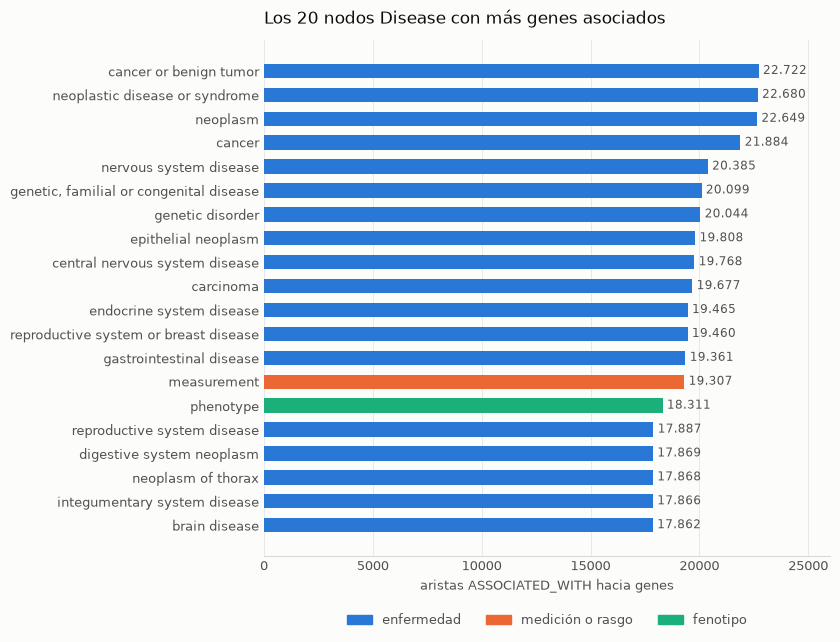

descendientes en la ontología de esos 20 nodos:
                                 nombre  genes  descendientes
                 cancer or benign tumor  22722           3592
         neoplastic disease or syndrome  22680           3518
                               neoplasm  22649           3364
                                 cancer  21884           1727
                 nervous system disease  20385           4157
genetic, familial or congenital disease  20099          10624
                       genetic disorder  20044          10077
                    epithelial neoplasm  19808           1101
         central nervous system disease  19768           2542
                              carcinoma  19677            799
               endocrine system disease  19465           1406
  reproductive system or breast disease  19460           1248
               gastrointestinal disease  19361           1308
                            measurement  19307          18667
                      

In [6]:
top = nodos.nlargest(20, "genes").sort_values("genes")

figura, ax = plt.subplots(figsize=(8.5, 6.5), facecolor=SUPERFICIE)
ax.set_facecolor(SUPERFICIE)
ax.barh(top["nombre"], top["genes"], height=0.6,
        color=[COLORES[c] for c in top["clase"]])
for y, (valor, descendientes) in enumerate(zip(top["genes"], top["descendientes"])):
    ax.text(valor + 200, y, f"{valor:,}".replace(",", "."), va="center", fontsize=8.5,
            color=TINTA_SUAVE)
preparar(ax, "Los 20 nodos Disease con más genes asociados", "aristas ASSOCIATED_WITH hacia genes")
ax.set_xlim(0, 26000)
manijas = [plt.Rectangle((0, 0), 1, 1, color=COLORES[c]) for c in ORDEN_CLASES if c in set(top["clase"])]
etiquetas = [c for c in ORDEN_CLASES if c in set(top["clase"])]
ax.legend(manijas, etiquetas, frameon=False, fontsize=9, labelcolor=TINTA_SUAVE,
          ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout()
plt.show()

print("descendientes en la ontología de esos 20 nodos:")
print(top[["nombre", "genes", "descendientes"]].sort_values("genes", ascending=False).to_string(index=False))

## La limpieza

Se conservan los nodos cuya clase es enfermedad, descartando además los que no tienen nombre
(términos obsoletos que quedaron del armado de la ontología y no representan nada consultable).

In [7]:
sin_nombre = nodos["nombre"].isna() | (nodos["nombre"].fillna("").str.strip() == "")
limpios = nodos[(nodos["clase"] == "enfermedad") & ~sin_nombre].copy()

print(f"capa completa:      {len(nodos):6d} nodos")
print(f"sin nombre:         {sin_nombre.sum():6d} nodos descartados")
for clase in ORDEN_CLASES[1:]:
    print(f"{clase:19s} {composicion[clase]:6d} nodos descartados")
print(f"quedan:             {len(limpios):6d} nodos ({100 * len(limpios) / len(nodos):.1f}% de la capa)")

capa completa:       36345 nodos
sin nombre:              4 nodos descartados
medición o rasgo     18654 nodos descartados
fenotipo               322 nodos descartados
procedimiento           57 nodos descartados
quedan:              17308 nodos (47.6% de la capa)


In [8]:
salida = "disease_ids_limpios.csv"
limpios[["id", "nombre", "prefijo", "genes", "descendientes"]].sort_values("id").to_csv(salida, index=False)

driver.close()